# Hate Speech Detection

The goal is to classify tweets as hate speech, offensive language, or neither. The dataset has 24,783 tweets, each labelled by the majority vote of several human annotators (`twitter.csv`, collected from Twitter and labelled for a research study on hate speech).

Reference solution: [Hate Speech Detection with Machine Learning](https://amanxai.com/2021/07/25/hate-speech-detection-with-machine-learning/) (Aman Kharwal). Dataset: [twitter.csv](https://github.com/amankharwal/Website-data/raw/master/twitter.csv).

The reference cleans the tweets (lower case, punctuation, stop words, stemming), counts the words (`CountVectorizer`), trains a Decision Tree on a 67/33 split and tests it on one example sentence. It reports no metric for the classes. Hate speech is only about 6% of the tweets, so this notebook looks at the score of every class, not only at accuracy.

In [1]:
import re
import string
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/NLP/hate_speech_detection')
nltk.download("stopwords", quiet=True)

True

## Data Loading

In [2]:
data = pd.read_csv("twitter.csv", index_col=0)
data.info()

<class 'pandas.DataFrame'>
Index: 24783 entries, 0 to 25296
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   count               24783 non-null  int64
 1   hate_speech         24783 non-null  int64
 2   offensive_language  24783 non-null  int64
 3   neither             24783 non-null  int64
 4   class               24783 non-null  int64
 5   tweet               24783 non-null  str  
dtypes: int64(5), str(1)
memory usage: 3.3 MB


## Exploratory Data Analysis

The column `class` holds the label (0 = hate speech, 1 = offensive language, 2 = neither). It is the majority vote of `count` annotators, and the columns `hate_speech`, `offensive_language` and `neither` give the number of votes for each class.

In [3]:
names = {0: "hate speech", 1: "offensive language", 2: "neither"}
data["label"] = data["class"].map(names)

votes = data[["hate_speech", "offensive_language", "neither"]]
data["agreement"] = votes.max(axis=1) / data["count"]

print(data["label"].value_counts(normalize=True).round(3))
print(data.groupby("label")["agreement"].mean().round(3))

label
offensive language    0.774
neither               0.168
hate speech           0.058
Name: proportion, dtype: float64
label
hate speech           0.728
neither               0.899
offensive language    0.919
Name: agreement, dtype: float64


Offensive language is 77% of the tweets and hate speech only 5.8%, so a model that always answers "offensive language" is right for 77% of the tweets. The annotators agree least on hate speech (on average 73% of the votes for the winning class, against 91% for offensive language and 92% for neither): the border between hate speech and offensive language is unclear even for people, which limits what any model can reach.

## Data Cleaning

The tweets contain retweet markers (`RT @user:`), user mentions, links and HTML codes (`&amp;`), which carry no information about the class. The cleaning is done on the whole column with pandas string methods: lower case, then removal of retweet markers, mentions, links, HTML codes, everything that is not a letter, and extra spaces. English stop words are removed by the vectorizer (`stop_words="english"`).

In [4]:
data["clean"] = (data["tweet"].str.lower()
                 .str.replace(r"rt @\w+:", " ", regex=True).str.replace(r"@\w+", " ", regex=True)
                 .str.replace(r"http\S+", " ", regex=True).str.replace(r"&\w+;", " ", regex=True)
                 .str.replace(r"[^a-z\s]", " ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip())

print("empty tweets after cleaning:", (data["clean"] == "").sum(), "| duplicated cleaned tweets:", data["clean"].duplicated().sum())
data[["tweet", "clean"]].head(3)

empty tweets after cleaning: 2 | duplicated cleaned tweets: 642


,tweet,clean
0,!!! RT @mayasolovely: As a woman you shouldn't...,as a woman you shouldn t complain about cleani...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,boy dats cold tyga dwn bad for cuffin dat hoe ...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg you ever fuck a bitch and she start to...


Some tweets have nothing left after cleaning, and many cleaned tweets repeat (retweets of the same text). Duplicates would put the same text in the training and in the test set, so the empty and the repeated tweets are removed. The labels of the repeated tweets could differ, which is checked first.

In [5]:
repeated = data[data["clean"].duplicated(keep=False) & (data["clean"] != "")]
print("repeated texts with different labels:", (repeated.groupby("clean")["class"].nunique() > 1).sum(), "out of", repeated["clean"].nunique())

data = data[data["clean"] != ""].drop_duplicates(subset="clean").reset_index(drop=True)
data["label"].value_counts()

repeated texts with different labels: 33 out of 354


label
offensive language    18681
neither                4077
hate speech            1382
Name: count, dtype: int64

## Reference Reproduction

The reference cleaning (lower case, removal of brackets, links, tags, punctuation, newlines, words with digits, stop words, then Snowball stemming), word counts, Decision Tree and a 33% test set are reproduced on the original data.

In [6]:
stemmer = nltk.SnowballStemmer("english")
stop_words = set(stopwords.words("english"))

def reference_clean(text):
    text = str(text).lower()
    text = re.sub(r"\[.*?\]", "", text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>+", "", text)
    text = re.sub("[%s]" % re.escape(string.punctuation), "", text)
    text = re.sub("\n", "", text)
    text = re.sub(r"\w*\d\w*", "", text)
    words = [word for word in text.split(" ") if word not in stop_words]
    return " ".join(stemmer.stem(word) for word in words)

raw = pd.read_csv("twitter.csv", index_col=0)
ref_x = CountVectorizer().fit_transform(raw["tweet"].apply(reference_clean))
ref_train, ref_test, ref_y_train, ref_y_test = train_test_split(ref_x, raw["class"].map(names), test_size=0.33, random_state=42)
ref_pred = DecisionTreeClassifier().fit(ref_train, ref_y_train).predict(ref_test)

print("reference accuracy:", round(accuracy_score(ref_y_test, ref_pred), 3))
print(classification_report(ref_y_test, ref_pred))

reference accuracy: 0.876
                    precision    recall  f1-score   support

       hate speech       0.38      0.33      0.35       465
           neither       0.82      0.80      0.81      1379
offensive language       0.92      0.93      0.93      6335

          accuracy                           0.88      8179
         macro avg       0.71      0.69      0.70      8179
      weighted avg       0.87      0.88      0.87      8179



## Feature Engineering

The cleaned tweets are split 80/20 and stratified, so that the rare hate speech class has the same share in both sets. Words are counted with `CountVectorizer(stop_words="english")`.

In [7]:
x_train, x_test, y_train, y_test = train_test_split(data["clean"], data["label"], test_size=0.2, random_state=42, stratify=data["label"])

vectorizer = CountVectorizer(stop_words="english", min_df=2).fit(x_train)
train_counts, test_counts = vectorizer.transform(x_train), vectorizer.transform(x_test)
print("features:", len(vectorizer.vocabulary_), "| training tweets:", len(x_train), "| test tweets:", len(x_test))

features: 7782 | training tweets: 19312 | test tweets: 4828


## Model Training

Four models are trained. The Logistic Regression is trained twice: once as it is and once with `class_weight="balanced"`, a parameter found while researching class imbalance (not covered in class) that gives the rare classes more weight during training.

In [8]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Logistic Regression, balanced": LogisticRegression(max_iter=1000, class_weight="balanced"),
}
predictions = {name: model.fit(train_counts, y_train).predict(test_counts) for name, model in models.items()}

## Evaluation

In [9]:
def scores(pred):
    report = classification_report(y_test, pred, output_dict=True)
    return {"Accuracy": report["accuracy"], "Macro F1": report["macro avg"]["f1-score"],
            "Hate precision": report["hate speech"]["precision"], "Hate recall": report["hate speech"]["recall"], "Hate F1": report["hate speech"]["f1-score"]}

pd.DataFrame({name: scores(p) for name, p in predictions.items()}).T.round(3)

,Accuracy,Macro F1,Hate precision,Hate recall,Hate F1
Decision Tree,0.889,0.713,0.382,0.332,0.355
Multinomial Naive Bayes,0.885,0.651,0.406,0.148,0.217
Logistic Regression,0.903,0.720,0.475,0.274,0.348
"Logistic Regression, balanced",0.868,0.735,0.312,0.603,0.411


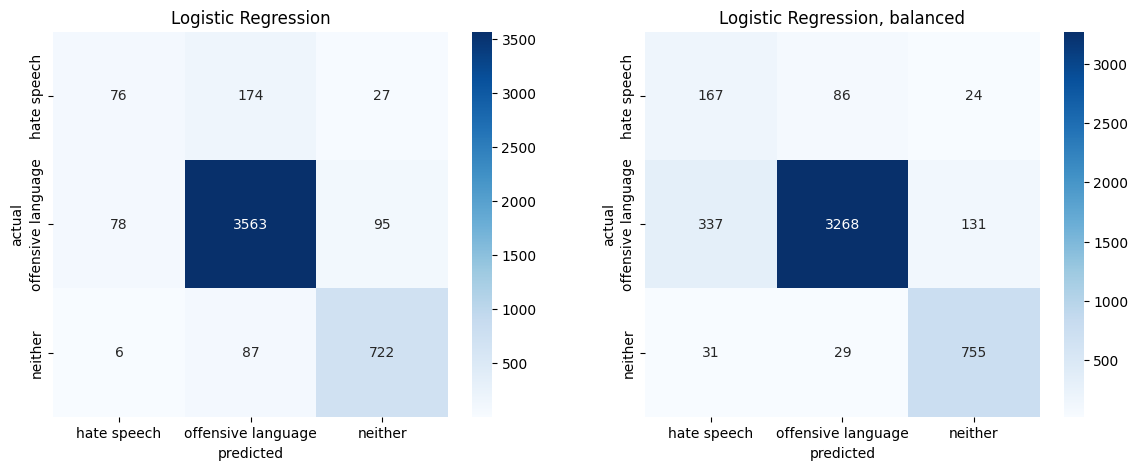

In [10]:
labels = ["hate speech", "offensive language", "neither"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ["Logistic Regression", "Logistic Regression, balanced"]):
    sns.heatmap(confusion_matrix(y_test, predictions[name], labels=labels), annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name); ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.show()

In [11]:
balanced = models["Logistic Regression, balanced"]
coefficients = pd.DataFrame(balanced.coef_.T, index=vectorizer.get_feature_names_out(), columns=balanced.classes_)
for label in balanced.classes_:
    print(label, "->", coefficients[label].sort_values(ascending=False).head(10).index.tolist())

hate speech -> ['faggot', 'faggots', 'nigger', 'fag', 'niggers', 'wetback', 'fags', 'dyke', 'nem', 'spic']
neither -> ['bird', 'charlie', 'yellow', 'yankees', 'birds', 'frustration', 'sole', 'acted', 'jihadi', 'buys']
offensive language -> ['bitches', 'bitch', 'pussy', 'pussies', 'hoes', 'hoe', 'shit', 'gon', 'cunt', 'fuck']


The reference tests its model with one sentence. The same sentence is tested with the two Logistic Regressions, together with a hateful message that contains no insult word and a harmless sentence.

In [12]:
sentences = ["Let's unite and kill all the people who are protesting against the government",
             "we should get rid of those people, they do not belong in this country",
             "the weather is so beautiful today, i love this city"]
probabilities = pd.DataFrame({name: [dict(zip(model.classes_, p.round(2))) for p in model.predict_proba(vectorizer.transform(sentences))]
                              for name, model in models.items() if name.startswith("Logistic")}, index=sentences)
probabilities

,Logistic Regression,"Logistic Regression, balanced"
Let's unite and kill all the people who are protesting against the government,"{'hate speech': 0.12, 'neither': 0.55, 'offens...","{'hate speech': 0.21, 'neither': 0.61, 'offens..."
"we should get rid of those people, they do not belong in this country","{'hate speech': 0.39, 'neither': 0.26, 'offens...","{'hate speech': 0.83, 'neither': 0.09, 'offens..."
"the weather is so beautiful today, i love this city","{'hate speech': 0.01, 'neither': 0.89, 'offens...","{'hate speech': 0.0, 'neither': 0.94, 'offensi..."


The reference Decision Tree reaches an accuracy of 0.876, but only a hate speech F1 of 0.35 (precision 0.38, recall 0.33): two thirds of the hate speech tweets of its test set are missed, which its single accuracy hides. Our cleaning (no stemming, retweet markers and mentions removed, duplicates removed) gives a similar Decision Tree (accuracy 0.889, hate F1 0.36).

Accuracy is a poor guide for this task. Logistic Regression has the highest accuracy (0.903) and the best hate speech precision (0.475), but finds only 27% of the hate speech tweets. Multinomial Naive Bayes finds 15%. Giving more weight to the rare classes (`class_weight="balanced"`) raises the recall of hate speech to 60%, the hate speech F1 to 0.41 and the macro F1 to 0.735, the best of the four models, at the price of more false alarms (hate speech precision 0.31) and a lower accuracy (0.868). Which model is better depends on the cost of a missed hate tweet against the cost of a wrongly flagged one. Even the best F1 stays at 0.41, because the class is small (5.8%) and ambiguous: the annotators agree on average on 73% of the votes for hate speech, against 90% for the other classes, and 33 of the 354 texts that appear several times in the data have different labels in different copies.

The words with the largest weights show what the models rely on. Hate speech is recognised by racial and homophobic slurs, offensive language by general profanity, and "neither" by incidental words ("bird", "yankees", "charlie"). The models therefore learn a list of words, not intent. The reference test sentence "Let's unite and kill all the people who are protesting against the government" is violent but has no insult: Logistic Regression gives it a probability of only 0.12 for hate speech (0.21 with class weights), and "neither" is its most likely class. The sentence "we should get rid of those people, they do not belong in this country" gets 0.39 without and 0.83 with class weights, so the outcome for texts without insult words depends strongly on the class weighting.

## Conclusion

**Reference approach.** The reference cleans the tweets (lower case, punctuation, stop words, stemming), counts the words, trains a Decision Tree on a 67/33 split and tests it with one hand-written sentence. It reports no score by class. Reproducing it gave an accuracy of 0.876 and a hate speech F1 of only 0.35.

**Data.** Offensive language is 77% of the tweets, "neither" 17% and hate speech 5.8%; the annotators agree least on hate speech (73% of the votes for the winning class on average). 642 cleaned tweets are duplicates (mostly retweets), 2 are empty, and 33 of the 354 repeated texts carry different labels in different copies, which is a sign of label noise. After removing the empty and the repeated tweets, 24,140 tweets are left.

**Results** (80/20 stratified split, 4,828 test tweets, hate speech scores):

| Model | Accuracy | Macro F1 | Hate precision | Hate recall | Hate F1 |
|---|---|---|---|---|---|
| Decision Tree | 0.889 | 0.713 | 0.382 | 0.332 | 0.355 |
| Multinomial Naive Bayes | 0.885 | 0.651 | 0.406 | 0.148 | 0.217 |
| Logistic Regression | 0.903 | 0.720 | 0.475 | 0.274 | 0.348 |
| Logistic Regression, balanced | 0.868 | 0.735 | 0.312 | 0.603 | 0.411 |

The model with the highest accuracy finds only 27% of the hate speech tweets. Class weights double the recall (0.60) at the cost of precision and accuracy, and give the best macro F1.

**What the models learn.** The largest weights are slurs for hate speech and profanity for offensive language, so the models recognise words and not the intent of a message. A violent message without insult words (the reference test sentence) is classified as "neither".

**Limitations.** The class is small and ambiguous, so every score for hate speech is uncertain and depends on one split. The labels are the majority vote of a few annotators, and the border between hate speech and offensive language is unclear even for them. Word counts cannot see context (quotes, reclaimed words, irony). The 33 conflicting duplicates show that a part of the labels cannot be predicted by any model. Hyperparameters and the decision threshold were not tuned; a lower threshold for hate speech would trade precision for recall in the same way as the class weights.